In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize= True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Data Cleaning

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

In [8]:
# Drop ID column (NO predictive value)
df.drop(columns=['customerID'], inplace=True)

## EXPLORATORY DATA ANALYSIS (EDA)

##### Target Distribution (WHY accuracy is misleading)

Why this plot exists: </br>
To prove class imbalance visually. Interviewers expect this

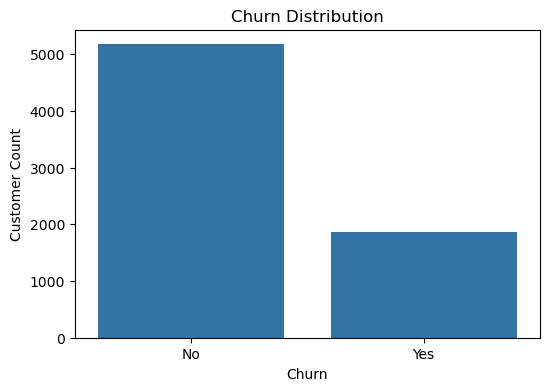

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()


##### Churn vs Contract Type (STRONG BUSINESS SIGNAL)

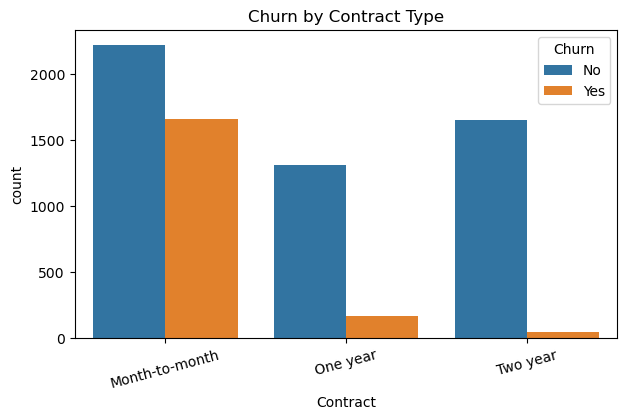

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()


##### Churn vs Tenure (BEHAVIORAL INSIGHT)

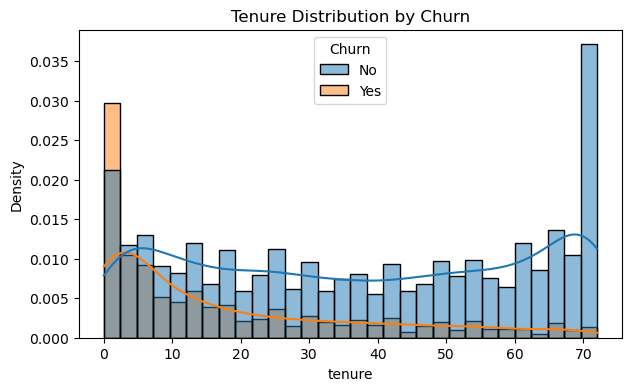

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    stat='density'
)
plt.title("Tenure Distribution by Churn")
plt.show()

##### Monthly Charges vs Churn (PRICING SENSITIVITY)

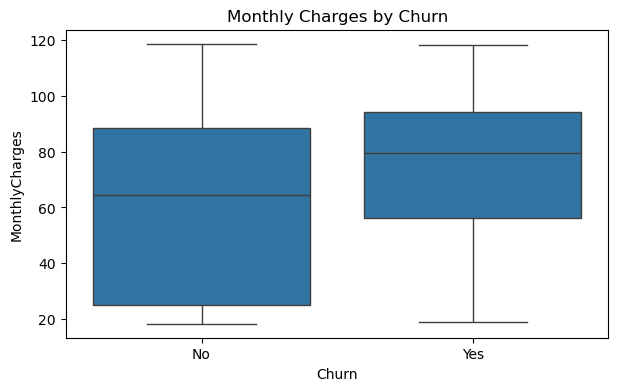

In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

##### Payment Method vs Churn (NON-OBVIOUS RISK)

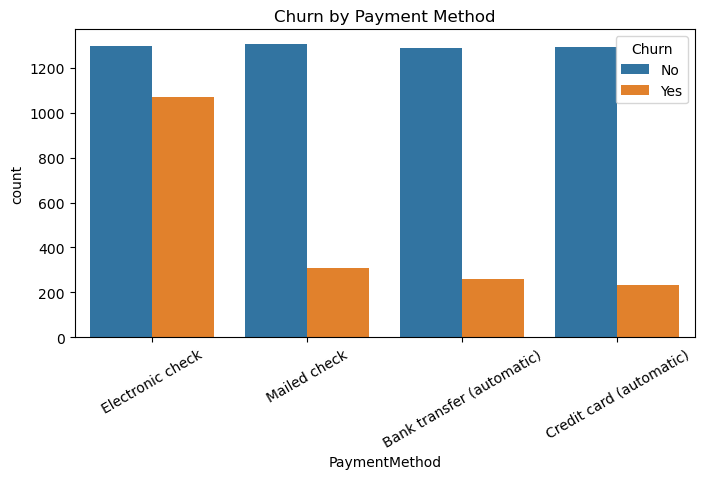

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)
plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

##### Internet Service vs Churn

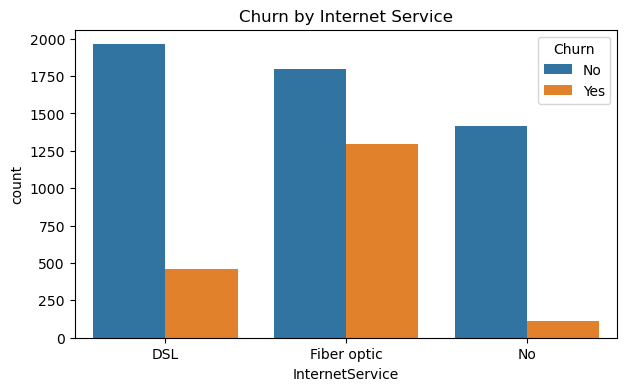

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.title("Churn by Internet Service")
plt.show()

## 📌 TRANSITION STATEMENT

## Feature Engineering

In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [16]:
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

df['service_count'] = (
    (df[['PhoneService','InternetService']] != 'No').sum(axis=1)
)

In [17]:
df['contract_risk'] = df['Contract'].apply(
    lambda x: 1 if x == 'Month-to-month' else 0
)

df['payment_risk'] = df['PaymentMethod'].apply(
    lambda x: 1 if x == 'Electronic check' else 0
)

## Feature / Target Split

In [18]:
# -----------------------------
# Feature Groups
# -----------------------------

target = "Churn"

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend",
    "service_count",
    "contract_risk",
    "payment_risk"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [19]:
X = df[numeric_features + categorical_features]
y = df[target]

## Train–Test Split (Stratified)
Why: Preserve churn ratio.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

# *****CREATE THE PREPROCESSOR  (New cell)*****

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False
)

stack = StackingClassifier(
    estimators=[
        ("cat", cat),
        ("lr", lr)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False
)

## BUILD THE PIPELINE

In [24]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", stack)   # your FINAL chosen model
])

# This wraps:
#     preprocessing
#     stacking ensemble
#     into one object.

## TRAIN THE PIPELINE

In [25]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'avg_monthly_spend',
                                                   'service_count',
                                                   'contract_risk',
                                                   'payment_risk']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSe...
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 StackingClassifier(estimators=[('cat',
                                                 <catboost.core.CatBoostClassifier object at 0x000002589354B4D0>),
                                                ('lr',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=1000))],
                                    final_estimator=LogisticRegression(max_iter=1000)))])

## EVALUATION

In [26]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

np.float64(0.8503039890914748)

## Threshold Optimization (BUSINESS LOGIC)

In [27]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1_scores)]
best_threshold

np.float64(0.3028357899345929)

## Final Classification Report

In [28]:
final_preds = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1294
           1       0.55      0.76      0.64       467

    accuracy                           0.77      1761
   macro avg       0.73      0.77      0.74      1761
weighted avg       0.81      0.77      0.78      1761



## Precision–Recall Curve (VISUAL)

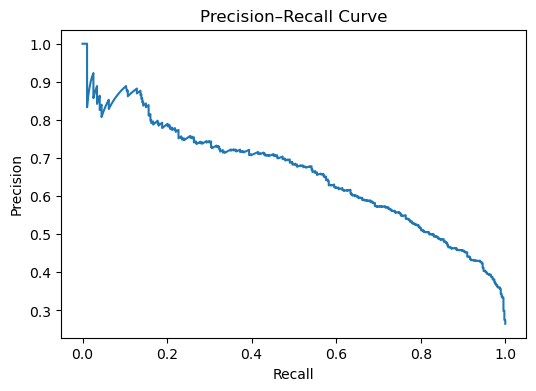

In [29]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

## SAVE THE PIPELINE

In [30]:
import joblib

joblib.dump(pipeline, "churn_pipeline.pkl")
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']

## Business Impact Summary

## Limitations & Future Work

## ATS-OPTIMIZED RESUME ENTRY (SHORT & POWERFUL)

#### ULTRA-SHORT VERSION (IF SPACE IS TIGHT)

## MOCK INTERVIEW EXPLANATION (HOW YOU SHOULD SPEAK)
##### 🎤 “Explain your churn prediction project.”

## INTERVIEW FOLLOW-UP QUESTIONS (WITH PERFECT ANSWERS)

## KILLER INTERVIEW STORY (STAR METHOD)

In [32]:
X_test


,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,service_count,contract_risk,payment_risk,gender,SeniorCitizen,Partner,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
5909,52,80.20,4297.60,81.086792,2,0,0,Female,0,No,...,Fiber optic,No,Yes,No,No,No,No,One year,Yes,Mailed check
3670,33,24.25,838.50,24.661765,1,1,0,Female,0,Yes,...,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic)
6220,10,53.70,521.00,47.363636,1,0,0,Male,0,Yes,...,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Credit card (automatic)
5905,1,85.00,85.00,42.500000,2,1,1,Male,0,No,...,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check
6435,52,50.20,2554.00,48.188679,1,0,0,Male,0,Yes,...,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,35,76.05,2747.20,76.311111,2,1,1,Male,1,Yes,...,DSL,No,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check
1607,13,89.05,1169.35,83.525000,2,1,0,Male,1,Yes,...,Fiber optic,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic)
6808,39,100.45,3801.70,95.042500,2,0,1,Male,0,No,...,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Electronic check
2962,3,31.00,95.05,23.762500,1,1,0,Female,0,Yes,...,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Mailed check
